# Analisis PCA - Dataset RRHH

Objetivo: determinar si PCA es una tecnica adecuada para reducir la dimensionalidad del dataset antes de aplicar clustering. Evaluaremos:
1. Preparacion de datos (escalado + encoding)
2. Matriz de correlacion entre variables numericas
3. Varianza explicada por cada componente principal
4. Decision: merece la pena aplicar PCA?

## 1. Carga de datos y exploracion inicial

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [5]:
df = pd.read_csv('dataSet_RRHH.csv')
print(f"Shape: {df.shape}")
print(f"\nTipos de datos:\n{df.dtypes}")
print(f"\nPrimeras filas:")
df.head()

Shape: (4900, 8)

Tipos de datos:
tenure_years         float64
age                  float64
salary_k             float64
performance_score    float64
absenteeism_days     float64
workload_index       float64
Department               str
Education_Level          str
dtype: object

Primeras filas:


,tenure_years,age,salary_k,performance_score,absenteeism_days,workload_index,Department,Education_Level
0,6.222330,41.652324,52.954657,66.099810,3.494094,8.545036,Finance,PhD
1,12.816358,50.229503,95.905314,94.516390,1.586166,7.587586,Sales,High School
2,7.373974,36.932161,55.760313,66.939439,3.416340,7.239733,IT,High School
3,-1.186950,28.009672,33.047192,55.782684,1.382140,5.927190,Finance,Bachelor
4,1.143603,26.930709,42.245990,91.035230,-0.270007,5.086634,Finance,PhD


In [6]:
# Estadisticas descriptivas de las variables numericas
df.describe().round(2)

,tenure_years,age,salary_k,performance_score,absenteeism_days,workload_index
count,4900.00,4900.00,4900.00,4900.00,4900.00,4900.00
mean,6.34,38.44,58.49,61.38,4.15,5.71
std,4.22,10.60,22.74,24.25,3.77,1.88
min,-2.72,16.84,17.72,10.17,-2.24,0.77
25%,2.41,25.94,38.60,38.33,1.48,4.18
50%,6.28,40.51,54.89,64.85,3.07,5.73
75%,10.24,47.09,81.42,83.56,5.53,7.20
max,15.12,58.39,111.22,108.99,15.38,11.85


## 2. Preprocesamiento

Para PCA necesitamos que todas las variables sean numericas y esten en la misma escala:
- **Variables numericas**: escalamos con `StandardScaler` (media=0, std=1)
- **Variables categoricas**: aplicamos one-hot encoding y luego escalamos tambien

In [7]:
# Separar variables numericas y categoricas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Variables numericas ({len(num_cols)}): {num_cols}")
print(f"Variables categoricas ({len(cat_cols)}): {cat_cols}")
for c in cat_cols:
    print(f"  {c}: {df[c].unique().tolist()}")

Variables numericas (6): ['tenure_years', 'age', 'salary_k', 'performance_score', 'absenteeism_days', 'workload_index']
Variables categoricas (2): ['Department', 'Education_Level']
  Department: ['Finance', 'Sales', 'IT', 'HR', 'Marketing']
  Education_Level: ['PhD', 'High School', 'Bachelor', 'Master']


In [8]:
# One-hot encoding de categoricas (drop_first para evitar multicolinealidad)
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)
print(f"Shape tras encoding: {df_encoded.shape}")
print(f"Columnas: {df_encoded.columns.tolist()}")

Shape tras encoding: (4900, 13)
Columnas: ['tenure_years', 'age', 'salary_k', 'performance_score', 'absenteeism_days', 'workload_index', 'Department_HR', 'Department_IT', 'Department_Marketing', 'Department_Sales', 'Education_Level_High School', 'Education_Level_Master', 'Education_Level_PhD']


In [9]:
# Escalado con StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)
X_scaled = pd.DataFrame(X_scaled, columns=df_encoded.columns)

print("Verificacion tras escalado (media ~ 0, std ~ 1):")
print(X_scaled.describe().loc[['mean', 'std']].round(4))

Verificacion tras escalado (media ~ 0, std ~ 1):
      tenure_years     age  salary_k  performance_score  absenteeism_days  \
mean       -0.0000  0.0000   -0.0000             0.0000            0.0000   
std         1.0001  1.0001    1.0001             1.0001            1.0001   

      workload_index  Department_HR  Department_IT  Department_Marketing  \
mean         -0.0000         0.0000        -0.0000                0.0000   
std           1.0001         1.0001         1.0001                1.0001   

      Department_Sales  Education_Level_High School  Education_Level_Master  \
mean           -0.0000                      -0.0000                 -0.0000   
std             1.0001                       1.0001                  1.0001   

      Education_Level_PhD  
mean               0.0000  
std                1.0001  


## 3. Matriz de correlacion

Antes de PCA, veamos si hay correlaciones fuertes entre variables. Si las variables son muy independientes entre si, PCA tendra poco que comprimir.

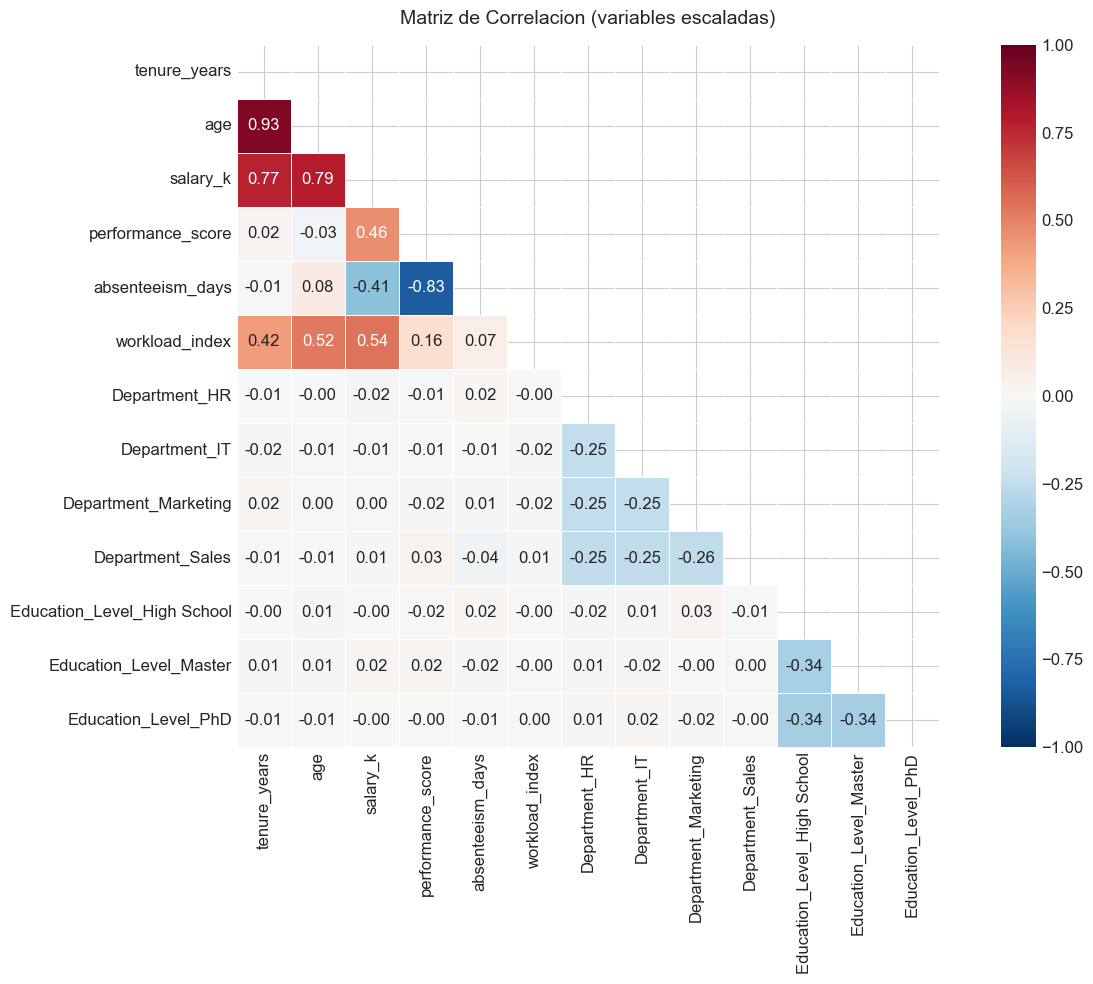


Top 10 correlaciones mas fuertes:
               Var1                   Var2  Correlacion
                age           tenure_years     0.927078
   absenteeism_days      performance_score    -0.834485
           salary_k                    age     0.785213
           salary_k           tenure_years     0.768077
     workload_index               salary_k     0.540722
     workload_index                    age     0.524468
  performance_score               salary_k     0.461874
     workload_index           tenure_years     0.423312
   absenteeism_days               salary_k    -0.412452
Education_Level_PhD Education_Level_Master    -0.337336


In [10]:
# Matriz de correlacion
corr_matrix = X_scaled.corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Matriz de Correlacion (variables escaladas)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Correlaciones mas fuertes (en valor absoluto)
corr_pairs = corr_matrix.where(mask == False).stack().reset_index()
corr_pairs.columns = ['Var1', 'Var2', 'Correlacion']
corr_pairs['abs_corr'] = corr_pairs['Correlacion'].abs()
print("\nTop 10 correlaciones mas fuertes:")
print(corr_pairs.nlargest(10, 'abs_corr')[['Var1', 'Var2', 'Correlacion']].to_string(index=False))

## 4. PCA - Analisis de componentes principales

Aplicamos PCA con **todos** los componentes para ver cuanta varianza explica cada uno. Esto nos permite decidir si merece la pena reducir dimensiones.

In [11]:
# PCA con todos los componentes
pca_full = PCA()
pca_full.fit(X_scaled)

# Varianza explicada por cada componente
var_explicada = pca_full.explained_variance_ratio_
var_acumulada = np.cumsum(var_explicada)

n_components = len(var_explicada)

# Tabla resumen
tabla_pca = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(n_components)],
    'Autovalor': pca_full.explained_variance_,
    'Varianza Explicada (%)': var_explicada * 100,
    'Varianza Acumulada (%)': var_acumulada * 100
}).round(4)

print(f"Numero total de componentes: {n_components}")
print(f"\n{'='*60}")
print(tabla_pca.to_string(index=False))
print(f"{'='*60}")

Numero total de componentes: 13

Componente  Autovalor  Varianza Explicada (%)  Varianza Acumulada (%)
       PC1     3.1110                 23.9261                 23.9261
       PC2     1.9300                 14.8434                 38.7696
       PC3     1.3508                 10.3889                 49.1584
       PC4     1.3453                 10.3464                 59.5048
       PC5     1.2525                  9.6326                 69.1374
       PC6     1.2399                  9.5354                 78.6728
       PC7     1.2345                  9.4940                 88.1668
       PC8     0.6892                  5.3002                 93.4670
       PC9     0.3277                  2.5199                 95.9869
      PC10     0.2442                  1.8780                 97.8650
      PC11     0.1284                  0.9877                 98.8526
      PC12     0.1011                  0.7773                 99.6300
      PC13     0.0481                  0.3700            

### 4.1 Scree Plot y Varianza Acumulada

El **scree plot** muestra la varianza explicada por cada componente. Buscamos un "codo" donde la ganancia marginal cae drasticamente. La linea de varianza acumulada nos dice cuantos componentes necesitamos para capturar un % deseado (tipicamente 80-90%).

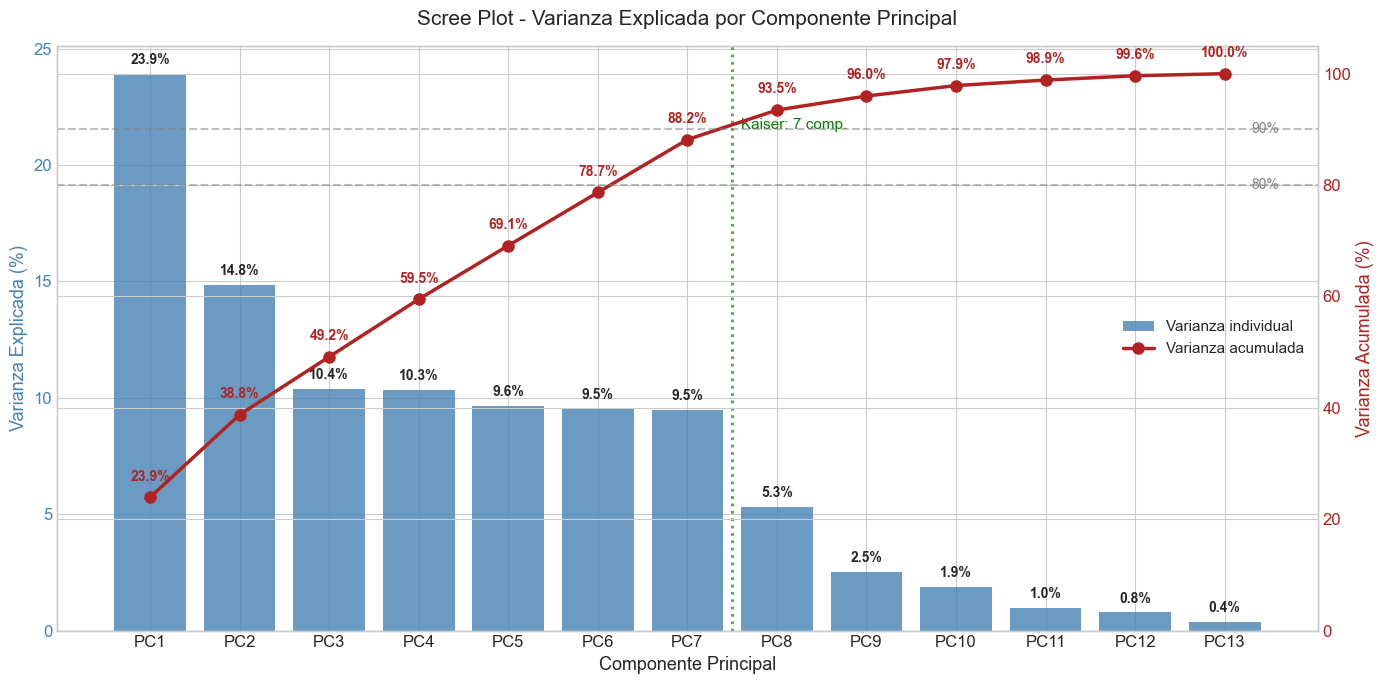


Criterio de Kaiser (autovalor > 1): retener 7 componentes
  -> Varianza acumulada con 7 componentes: 88.2%
  -> Componentes para >=80% varianza: 7
  -> Componentes para >=90% varianza: 8


In [12]:
fig, ax1 = plt.subplots(figsize=(14, 7))

# Barras: varianza individual
x = np.arange(1, n_components + 1)
bars = ax1.bar(x, var_explicada * 100, color='steelblue', alpha=0.8, label='Varianza individual')

# Etiquetas sobre las barras
for bar, val in zip(bars, var_explicada * 100):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_xlabel('Componente Principal', fontsize=13)
ax1.set_ylabel('Varianza Explicada (%)', fontsize=13, color='steelblue')
ax1.set_xticks(x)
ax1.set_xticklabels([f'PC{i}' for i in x])
ax1.tick_params(axis='y', labelcolor='steelblue')

# Linea: varianza acumulada
ax2 = ax1.twinx()
ax2.plot(x, var_acumulada * 100, 'o-', color='firebrick', linewidth=2.5,
         markersize=8, label='Varianza acumulada')

# Etiquetas en la linea acumulada
for xi, val in zip(x, var_acumulada * 100):
    ax2.annotate(f'{val:.1f}%', (xi, val), textcoords="offset points",
                 xytext=(0, 12), ha='center', fontsize=10, color='firebrick', fontweight='bold')

ax2.set_ylabel('Varianza Acumulada (%)', fontsize=13, color='firebrick')
ax2.tick_params(axis='y', labelcolor='firebrick')
ax2.set_ylim(0, 105)

# Lineas de referencia
for threshold in [80, 90]:
    ax2.axhline(y=threshold, color='gray', linestyle='--', alpha=0.5)
    ax2.text(n_components + 0.3, threshold, f'{threshold}%', va='center', fontsize=10, color='gray')

# Criterio de Kaiser: autovalor > 1
n_kaiser = sum(pca_full.explained_variance_ > 1)
ax1.axvline(x=n_kaiser + 0.5, color='green', linestyle=':', linewidth=2, alpha=0.7)
ax1.text(n_kaiser + 0.6, max(var_explicada * 100) * 0.9,
         f'Kaiser: {n_kaiser} comp.', color='green', fontsize=11)

ax1.set_title('Scree Plot - Varianza Explicada por Componente Principal', fontsize=15, pad=15)

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=11)

plt.tight_layout()
plt.show()

print(f"\nCriterio de Kaiser (autovalor > 1): retener {n_kaiser} componentes")
print(f"  -> Varianza acumulada con {n_kaiser} componentes: {var_acumulada[n_kaiser-1]*100:.1f}%")

# Componentes para 80% y 90%
for threshold in [0.80, 0.90]:
    n_thresh = np.argmax(var_acumulada >= threshold) + 1
    print(f"  -> Componentes para >={threshold*100:.0f}% varianza: {n_thresh}")

### 4.2 Peso de cada variable original en los componentes principales

Para interpretar que representa cada componente, vemos los loadings (pesos) de las variables originales.

In [13]:
# Loadings (pesos de cada variable en cada componente)
loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=df_encoded.columns
)

# Mostrar los loadings de los primeros componentes relevantes
n_show = min(n_components, 6)
print(f"Loadings de los primeros {n_show} componentes:\n")
print(loadings.iloc[:, :n_show].round(3).to_string())

Loadings de los primeros 6 componentes:

                               PC1    PC2    PC3    PC4    PC5    PC6
tenure_years                 0.496  0.222 -0.008  0.005 -0.001 -0.001
age                          0.502  0.281 -0.011  0.001  0.013  0.017
salary_k                     0.540 -0.113  0.008 -0.015 -0.021  0.000
performance_score            0.208 -0.633  0.034 -0.022 -0.059 -0.018
absenteeism_days            -0.160  0.656 -0.036  0.022  0.058  0.016
workload_index               0.374  0.127 -0.027 -0.018  0.036  0.009
Department_HR               -0.010  0.028 -0.237  0.095 -0.423 -0.133
Department_IT               -0.012 -0.005  0.010 -0.251 -0.161  0.769
Department_Marketing         0.002  0.045  0.281  0.057 -0.269 -0.551
Department_Sales             0.010 -0.079 -0.055  0.089  0.842 -0.084
Education_Level_High School -0.002  0.044  0.717 -0.242  0.035  0.026
Education_Level_Master       0.016 -0.033 -0.144  0.763 -0.064  0.183
Education_Level_PhD         -0.008 -0.015 -0.570 

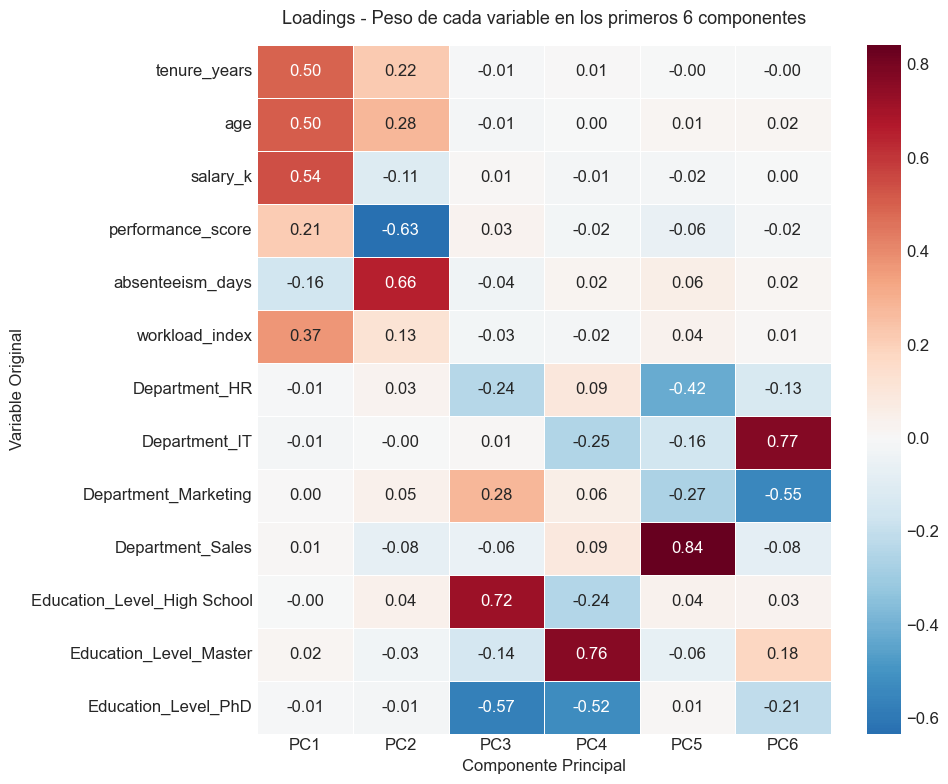

In [14]:
# Heatmap de loadings para los primeros componentes
n_show = min(n_components, 6)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(loadings.iloc[:, :n_show], annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax)
ax.set_title(f'Loadings - Peso de cada variable en los primeros {n_show} componentes', fontsize=13, pad=15)
ax.set_xlabel('Componente Principal')
ax.set_ylabel('Variable Original')
plt.tight_layout()
plt.show()

## 5. Conclusion: Merece la pena aplicar PCA?

Criterios para decidir:

| Criterio | A favor de PCA | En contra de PCA |
|---|---|---|
| **Varianza acumulada** | Pocos componentes capturan >80% | Necesitas casi todos para >80% |
| **Scree plot** | Codo claro y pronunciado | Caida gradual y uniforme |
| **Kaiser** | Pocos componentes con autovalor >1 | Muchos componentes con autovalor >1 |
| **Correlaciones** | Variables correlacionadas (redundancia) | Variables independientes |
| **Dimensionalidad** | Muchas variables originales | Pocas variables originales |

**Nota**: Con solo 12 variables totales (6 num + 6 dummies tras encoding), la reduccion dimensional solo merece la pena si hay correlaciones fuertes que PCA pueda aprovechar. Ejecuta las celdas anteriores y usa la tabla y graficas para llegar a tu conclusion.